In [109]:
#Imports numpy for math, matplotlib for visualizations, noiseProjectBase for base numerical methods and sampling.
import numpy as np
import matplotlib.pyplot as plt
import noiseProjectBase as npb

In [110]:
#Generates a selected color of noise by constructing its desired PSD in frequency space and transforming it into the time domain.
#Inputs: color selects the noise type, sigma sets the target standard deviation, tau sets the characteristic timescale, deltat is the timestep, tmax is the total time, and seed sets the random seed.
#Outputs: Time-domain noise, frequency information, target and generated PSDs, and the correlation function.
def generateNoise(color, sigma, tau, deltat, tmax, seed=None):
    if seed is not None:
        np.random.seed(seed)

    #Creates the frequency and angular-frequency grids.
    frequencyList = np.fft.rfftfreq(int(tmax/deltat), deltat)
    omegaList = 2*np.pi*frequencyList
    psdList = np.zeros(len(omegaList))
    psdList[0] = 0.0

    #Defines the desired PSD frequency dependence for each noise color.
    for i in range(1, len(omegaList)):
        omega = omegaList[i]
        if color.lower()=="white":
            psd = 1.0
        elif color.lower()=="pink":
            psd = 1.0/np.sqrt(omega*omega+(1/tau)*(1/tau))
        elif color.lower()=="red":
            psd = 1.0/(omega*omega+(1/tau)*(1/tau))
        elif color.lower()=="blue":
            psd = omega
        elif color.lower()=="violet":
            psd = omega*omega
        elif color.lower()=="lorentzian":
            psd = sigma*sigma*tau/(np.pi*(1+omega*omega*tau*tau))
        else:
            psd = 0.0
        psdList[i] = psd

    #Assigns a random phase to each frequency component and weights its amplitude using the PSD.
    randomPhase = np.random.uniform(0.0, 2.0*np.pi, len(psdList))
    frequencyNoise = np.sqrt(psdList)*np.exp(1.0j*randomPhase)
    frequencyNoise[0] = 0.0

    #Ensures the Nyquist-frequency component is real when the number of time points is even.
    if int(tmax/deltat)%2==0:
        if np.cos(randomPhase[-1])>=0.0:
            frequencyNoise[-1] = np.sqrt(psdList[-1])
        else:
            frequencyNoise[-1] = -np.sqrt(psdList[-1])

    #Transforms the noise back into the time domain and normalizes it to the target standard deviation.
    noiseList = np.fft.irfft(frequencyNoise, int(tmax/deltat))
    noiseList = noiseList-np.mean(noiseList)
    noiseList = noiseList*np.sqrt((sigma*sigma)/np.var(noiseList))
    timeList = np.arange(int(tmax/deltat))*deltat

    #Calculates the PSD produced by the generated time-domain noise.
    generatedPSD = deltat/int(tmax/deltat)*np.abs(np.fft.rfft(noiseList))*np.abs(np.fft.rfft(noiseList))

    #Calculates the autocorrelation of the generated noise using the Fourier transform.
    correlationFFT = np.fft.fft(noiseList-np.mean(noiseList), 2*int(tmax/deltat))
    correlationList = np.fft.ifft(correlationFFT*np.conjugate(correlationFFT)).real[:int(tmax/deltat)]

    #Corrects for the decreasing number of overlapping points at larger time separations.
    correlationList = correlationList/np.arange(int(tmax/deltat), 0, -1)
    spaceList = np.arange(int(tmax/deltat))*deltat

    return timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList

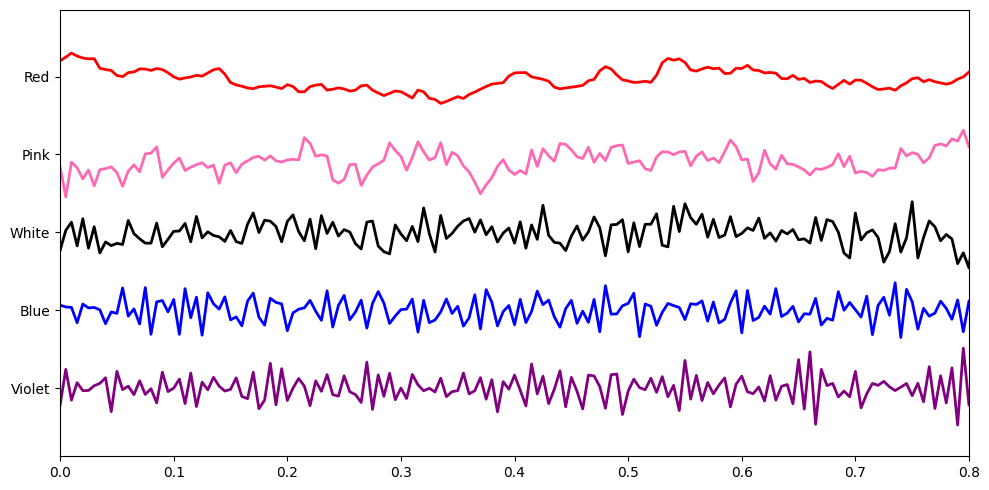

In [111]:
#Defines the common noise strength, timestep, simulation time, and characteristic timescale used for the time-domain comparison.
sigma = 2.0
deltat = 0.005
tmax = 15.0
tau = 0.1

#Defines the five noise colors and their plotting labels and colors.
noiseTypes = ["red", "pink", "white", "blue", "violet"]
noiseLabels = {"red": "Red", "pink": "Pink", "white": "White", "blue": "Blue", "violet": "Violet"}
noiseColors = {"red": "red", "pink": "hotpink", "white": "black", "blue": "blue", "violet": "purple"}

#Creates vertical offsets so the five time-domain traces can be viewed separately on the same graph.
offsetStep = 12.0
offsets = np.arange(len(noiseTypes))[::-1]*offsetStep

plt.figure(figsize=(10, 5))

#Generates and plots one realization of each noise color.
for index, noiseType in enumerate(noiseTypes):
    timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise(noiseType, sigma, tau, deltat, tmax, seed=1+index)
    plt.plot(timeList, noiseList+offsets[index], color=noiseColors[noiseType], linewidth=2.0)

#plt.xlabel("Time", fontsize=16)
#plt.ylabel("Noise Color", fontsize=16)
#plt.title("Different Colors of Noise in the Time Domain", fontsize=20)

#Labels each vertically offset trace by its noise color.
plt.yticks(offsets, [noiseLabels[noiseType] for noiseType in noiseTypes])
plt.xlim(0, 0.8)
#plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

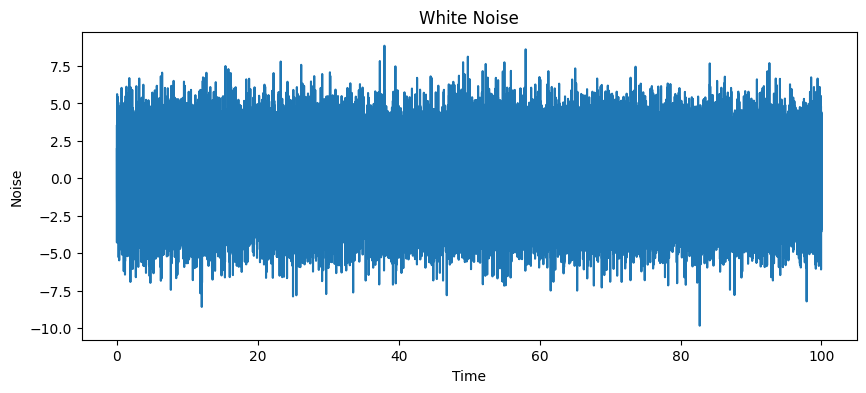

In [112]:
#Defines the parameters and generates one white-noise realization.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("white", sigma, tau, deltat, tmax, seed=1)

#Plots white noise in the time domain.
plt.figure(figsize=(10, 4))
plt.plot(timeList, noiseList)
plt.xlabel("Time")
plt.ylabel("Noise")
plt.title("White Noise")
plt.show()

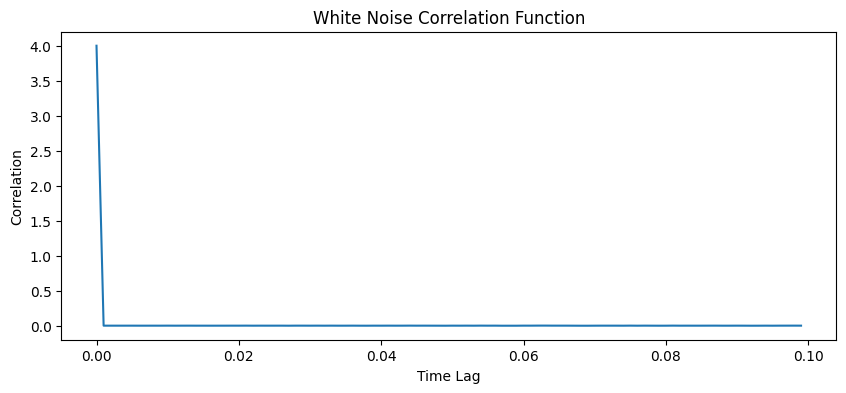

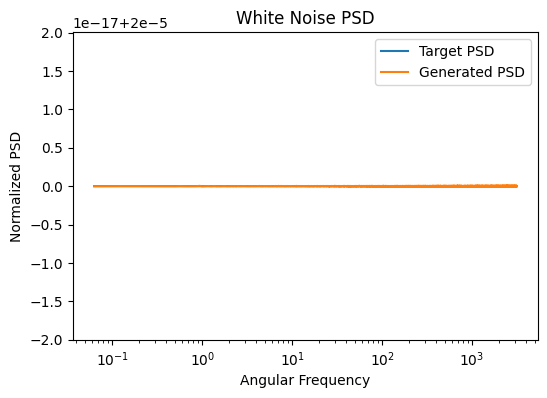

In [113]:
#Defines the parameters and generates white noise along with its correlation function and PSD.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("white", sigma, tau, deltat, tmax, seed=1)

#Plots the white-noise correlation function over a short time-lag range.
maxSpace = 0.1
maxSpaceIndex = int(maxSpace/deltat)
plt.figure(figsize=(10, 4))
plt.plot(spaceList[:maxSpaceIndex], correlationList[:maxSpaceIndex])
plt.xlabel("Time Lag")
plt.ylabel("Correlation")
plt.title("White Noise Correlation Function")
plt.show()

#Normalizes and compares the target white-noise PSD with the PSD of the generated signal.
targetPSDNormalized = psdList/np.sum(psdList)
generatedPSDNormalized = generatedPSD/np.sum(generatedPSD)

plt.figure(figsize=(6, 4))
plt.semilogx(omegaList[1:], targetPSDNormalized[1:], label="Target PSD")
plt.semilogx(omegaList[1:], generatedPSDNormalized[1:], label="Generated PSD")
plt.xlabel("Angular Frequency")
plt.ylabel("Normalized PSD")
plt.title("White Noise PSD")
plt.legend()
plt.show()

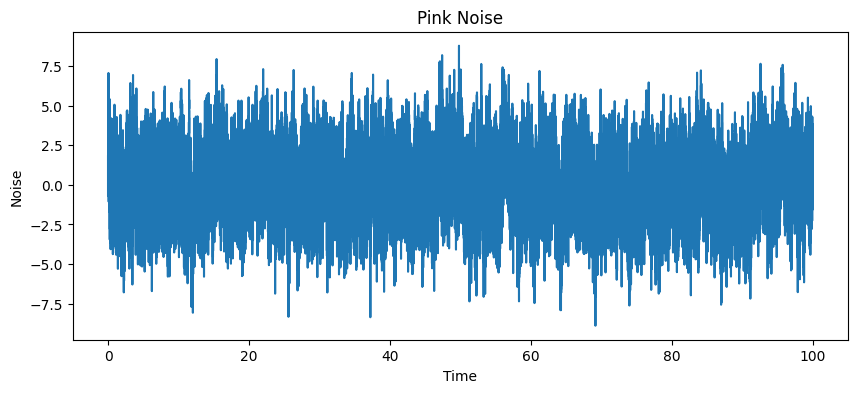

In [114]:
#Defines the parameters and generates one pink-noise realization.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("pink", sigma, tau, deltat, tmax, seed=1)

#Plots pink noise in the time domain.
plt.figure(figsize=(10, 4))
plt.plot(timeList, noiseList)
plt.xlabel("Time")
plt.ylabel("Noise")
plt.title("Pink Noise")
plt.show()

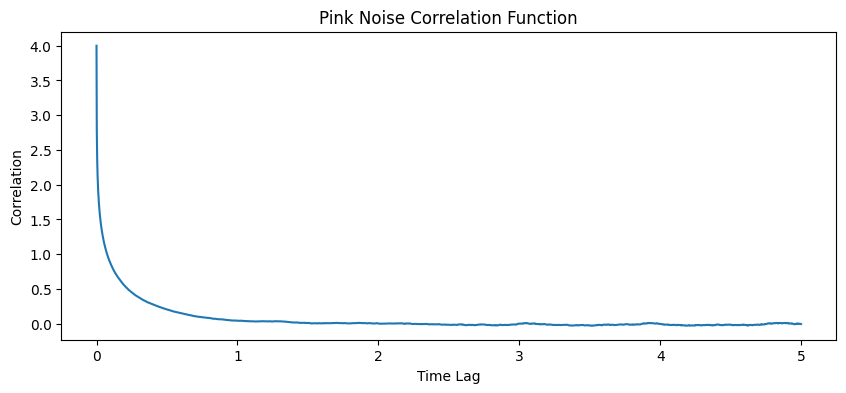

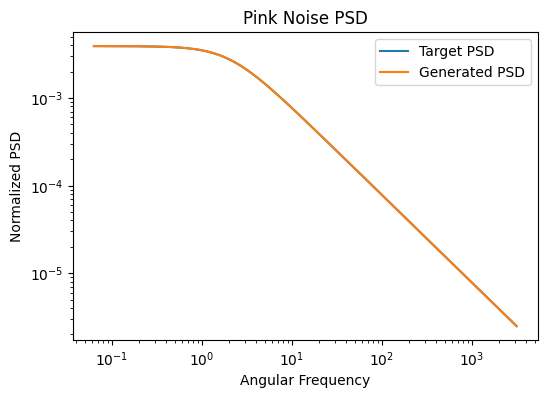

In [115]:
#Defines the parameters and generates pink noise along with its correlation function and PSD.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("pink", sigma, tau, deltat, tmax, seed=1)

#Plots the pink-noise correlation function.
maxSpace = 5.0
maxSpaceIndex = int(maxSpace/deltat)
plt.figure(figsize=(10, 4))
plt.plot(spaceList[:maxSpaceIndex], correlationList[:maxSpaceIndex])
plt.xlabel("Time Lag")
plt.ylabel("Correlation")
plt.title("Pink Noise Correlation Function")
plt.show()

#Normalizes and compares the target pink-noise PSD with the PSD of the generated signal.
targetPSDNormalized = psdList/np.sum(psdList)
generatedPSDNormalized = generatedPSD/np.sum(generatedPSD)

plt.figure(figsize=(6, 4))
plt.loglog(omegaList[1:], targetPSDNormalized[1:], label="Target PSD")
plt.loglog(omegaList[1:], generatedPSDNormalized[1:], label="Generated PSD")
plt.xlabel("Angular Frequency")
plt.ylabel("Normalized PSD")
plt.title("Pink Noise PSD")
plt.legend()
plt.show()

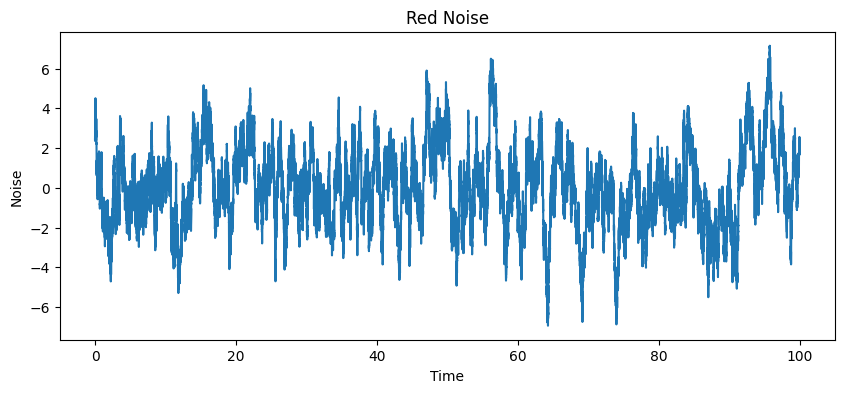

In [116]:
#Defines the parameters and generates one red-noise realization.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("red", sigma, tau, deltat, tmax, seed=1)

#Plots red noise in the time domain.
plt.figure(figsize=(10, 4))
plt.plot(timeList, noiseList)
plt.xlabel("Time")
plt.ylabel("Noise")
plt.title("Red Noise")
plt.show()

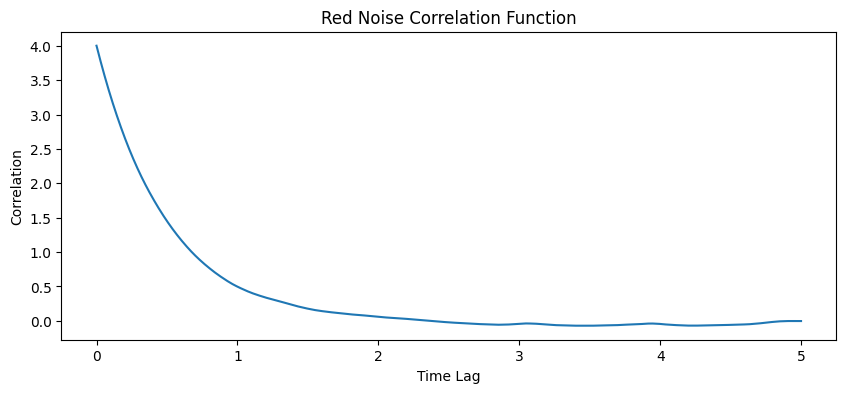

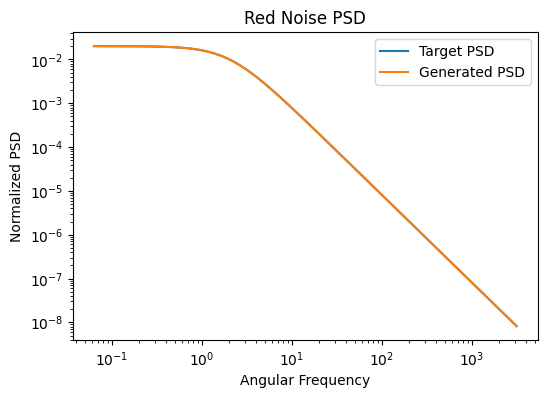

In [117]:
#Defines the parameters and generates red noise along with its correlation function and PSD.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("red", sigma, tau, deltat, tmax, seed=1)

#Plots the red-noise correlation function.
maxSpace = 5.0
maxSpaceIndex = int(maxSpace/deltat)
plt.figure(figsize=(10, 4))
plt.plot(spaceList[:maxSpaceIndex], correlationList[:maxSpaceIndex])
plt.xlabel("Time Lag")
plt.ylabel("Correlation")
plt.title("Red Noise Correlation Function")
plt.show()

#Normalizes and compares the target red-noise PSD with the PSD of the generated signal.
targetPSDNormalized = psdList/np.sum(psdList)
generatedPSDNormalized = generatedPSD/np.sum(generatedPSD)

plt.figure(figsize=(6, 4))
plt.loglog(omegaList[1:], targetPSDNormalized[1:], label="Target PSD")
plt.loglog(omegaList[1:], generatedPSDNormalized[1:], label="Generated PSD")
plt.xlabel("Angular Frequency")
plt.ylabel("Normalized PSD")
plt.title("Red Noise PSD")
plt.legend()
plt.show()

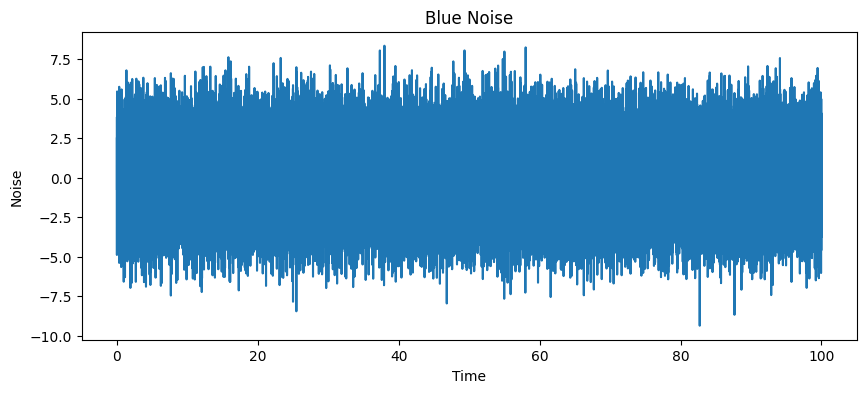

In [118]:
#Defines the parameters and generates one blue-noise realization.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("blue", sigma, tau, deltat, tmax, seed=1)

#Plots blue noise in the time domain.
plt.figure(figsize=(10, 4))
plt.plot(timeList, noiseList)
plt.xlabel("Time")
plt.ylabel("Noise")
plt.title("Blue Noise")
plt.show()

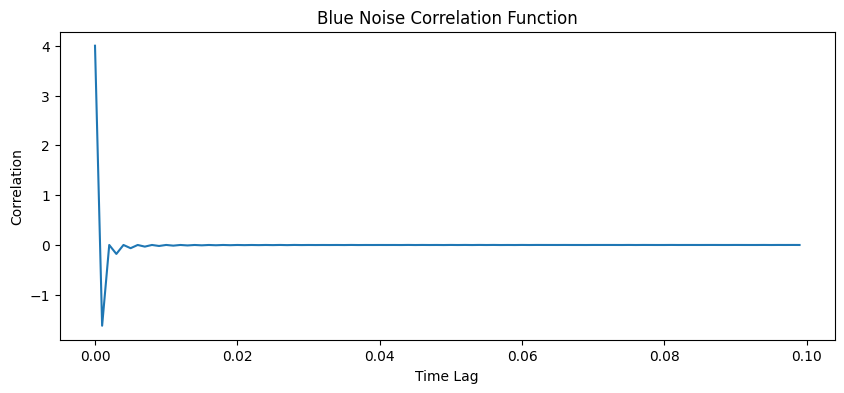

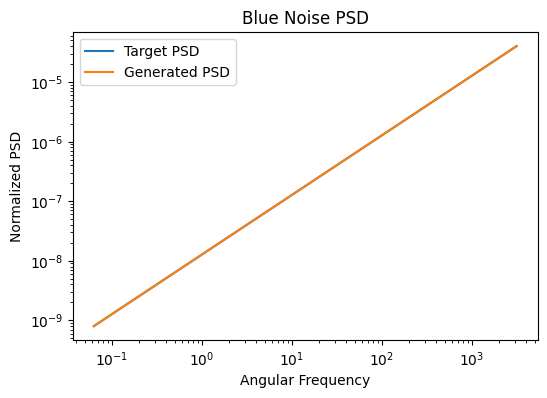

In [119]:
#Defines the parameters and generates blue noise along with its correlation function and PSD.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("blue", sigma, tau, deltat, tmax, seed=1)

#Plots the blue-noise correlation function over a short time-lag range.
maxSpace = 0.1
maxSpaceIndex = int(maxSpace/deltat)
plt.figure(figsize=(10, 4))
plt.plot(spaceList[:maxSpaceIndex], correlationList[:maxSpaceIndex])
plt.xlabel("Time Lag")
plt.ylabel("Correlation")
plt.title("Blue Noise Correlation Function")
plt.show()

#Normalizes and compares the target blue-noise PSD with the PSD of the generated signal.
targetPSDNormalized = psdList/np.sum(psdList)
generatedPSDNormalized = generatedPSD/np.sum(generatedPSD)

plt.figure(figsize=(6, 4))
plt.loglog(omegaList[1:], targetPSDNormalized[1:], label="Target PSD")
plt.loglog(omegaList[1:], generatedPSDNormalized[1:], label="Generated PSD")
plt.xlabel("Angular Frequency")
plt.ylabel("Normalized PSD")
plt.title("Blue Noise PSD")
plt.legend()
plt.show()

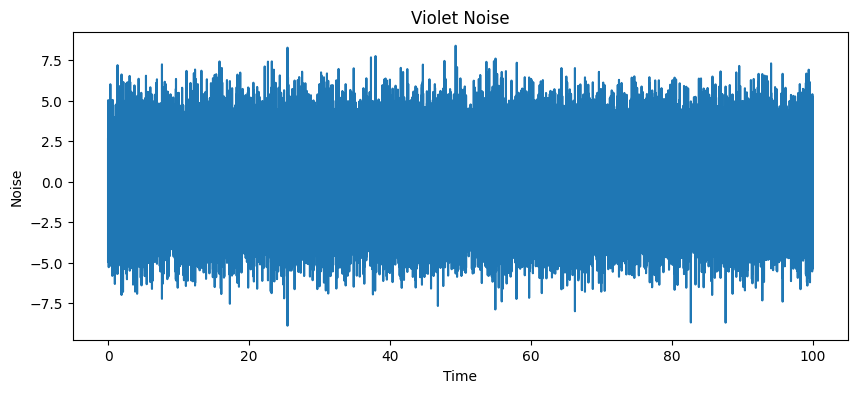

In [120]:
#Defines the parameters and generates one violet-noise realization.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("violet", sigma, tau, deltat, tmax, seed=1)

#Plots violet noise in the time domain.
plt.figure(figsize=(10, 4))
plt.plot(timeList, noiseList)
plt.xlabel("Time")
plt.ylabel("Noise")
plt.title("Violet Noise")
plt.show()

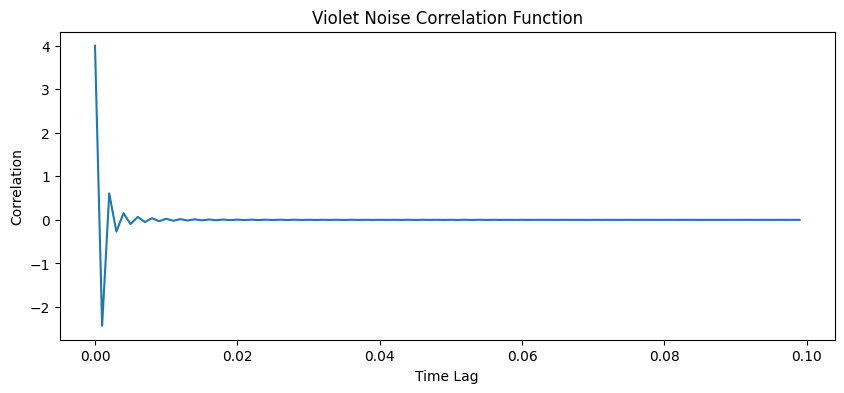

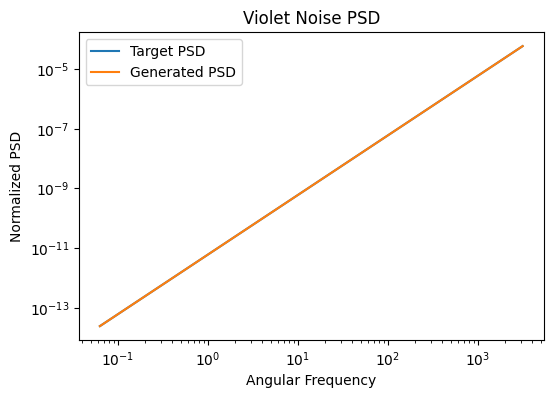

In [121]:
#Defines the parameters and generates violet noise along with its correlation function and PSD.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("violet", sigma, tau, deltat, tmax, seed=1)

#Plots the violet-noise correlation function over a short time-lag range.
maxSpace = 0.1
maxSpaceIndex = int(maxSpace/deltat)
plt.figure(figsize=(10, 4))
plt.plot(spaceList[:maxSpaceIndex], correlationList[:maxSpaceIndex])
plt.xlabel("Time Lag")
plt.ylabel("Correlation")
plt.title("Violet Noise Correlation Function")
plt.show()

#Normalizes and compares the target violet-noise PSD with the PSD of the generated signal.
targetPSDNormalized = psdList/np.sum(psdList)
generatedPSDNormalized = generatedPSD/np.sum(generatedPSD)

plt.figure(figsize=(6, 4))
plt.loglog(omegaList[1:], targetPSDNormalized[1:], label="Target PSD")
plt.loglog(omegaList[1:], generatedPSDNormalized[1:], label="Generated PSD")
plt.xlabel("Angular Frequency")
plt.ylabel("Normalized PSD")
plt.title("Violet Noise PSD")
plt.legend()
plt.show()

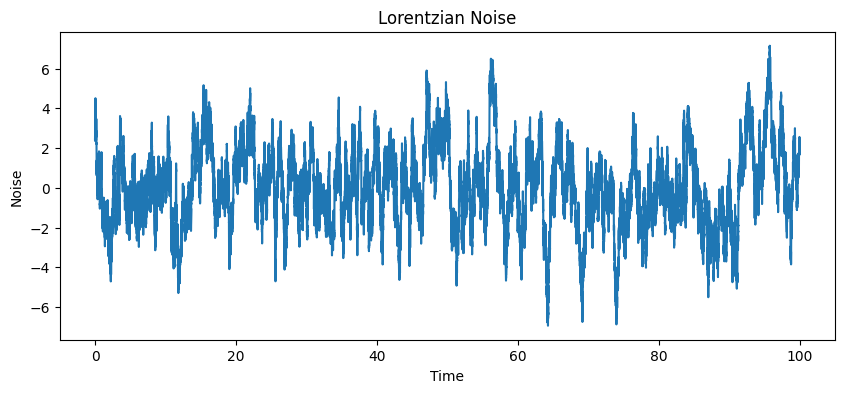

In [122]:
#Defines the parameters and generates one Lorentzian-noise realization.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("lorentzian", sigma, tau, deltat, tmax, seed=1)

#Plots Lorentzian noise in the time domain.
plt.figure(figsize=(10, 4))
plt.plot(timeList, noiseList)
plt.xlabel("Time")
plt.ylabel("Noise")
plt.title("Lorentzian Noise")
plt.show()

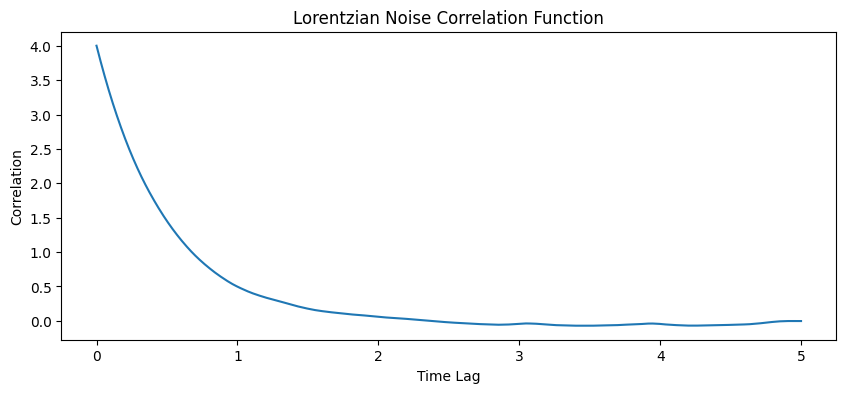

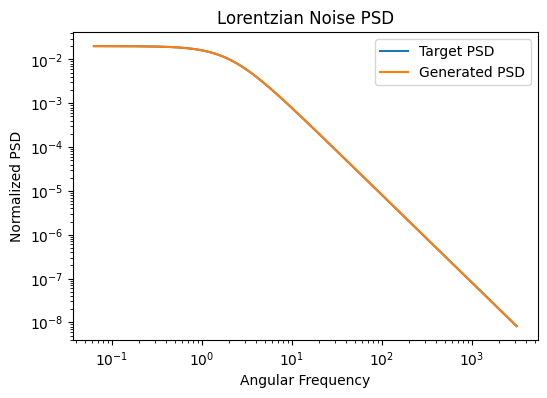

In [123]:
#Defines the parameters and generates Lorentzian noise along with its correlation function and PSD.
sigma = 2.0
deltat = 0.001
tmax = 100.0
tau = 0.5
timeList, noiseList, frequencyList, omegaList, psdList, generatedPSD, spaceList, correlationList = generateNoise("lorentzian", sigma, tau, deltat, tmax, seed=1)

#Plots the Lorentzian-noise correlation function.
maxSpace = 5.0
maxSpaceIndex = int(maxSpace/deltat)
plt.figure(figsize=(10, 4))
plt.plot(spaceList[:maxSpaceIndex], correlationList[:maxSpaceIndex])
plt.xlabel("Time Lag")
plt.ylabel("Correlation")
plt.title("Lorentzian Noise Correlation Function")
plt.show()

#Normalizes and compares the target Lorentzian PSD with the PSD of the generated signal.
targetPSDNormalized = psdList/np.sum(psdList)
generatedPSDNormalized = generatedPSD/np.sum(generatedPSD)

plt.figure(figsize=(6, 4))
plt.loglog(omegaList[1:], targetPSDNormalized[1:], label="Target PSD")
plt.loglog(omegaList[1:], generatedPSDNormalized[1:], label="Generated PSD")
plt.xlabel("Angular Frequency")
plt.ylabel("Normalized PSD")
plt.title("Lorentzian Noise PSD")
plt.legend()
plt.show()